\
# Generating Ornstein-Uhlenbeck trajectories with a conditional diffusion model

The Ornstein-Uhlenbeck (OU) process is the simplest nontrivial target for a
generative model of stochastic dynamics: linear, Gaussian, and equipped with
closed-form statistics. This makes it an ideal sanity check, because both the
stationary distribution **and** the autocorrelation function can be overlaid
as analytic curves against the diffusion model's samples.

Workflow:

1. Simulate an ensemble of OU trajectories with random parameters
   $(\theta, D)$;
2. Train a conditional diffusion model (DDPM denoiser, DDIM sampler);
3. Generate trajectories for held-out parameter pairs;
4. Compare against the analytic benchmarks.

In [1]:
\
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import norm
from torch.utils.data import TensorDataset

from diffusionsde import DDPM, DiffusionConfig, configure_matplotlib
from diffusionsde.evaluator import sample_acf
from diffusionsde.plotting import (
    GENERATED_COLOUR,
    REFERENCE_COLOUR,
    plot_acf_comparison,
    plot_marginal_distribution,
)

configure_matplotlib()

torch.manual_seed(42)
np.random.seed(42)

\
## 1. The Ornstein-Uhlenbeck process

$$\mathrm{d}x = -\theta x\,\mathrm{d}t + \sqrt{2D}\,\mathrm{d}W,$$

with relaxation rate $\theta > 0$ and diffusivity $D > 0$. Starting from
$x(0) = 0$, the process relaxes to the stationary state

$$p_{\mathrm{st}}(x) = \mathcal{N}\!\left(0,\ \frac{D}{\theta}\right),
\qquad
\rho(\tau) = \frac{\langle x(t)x(t+\tau)\rangle}{\langle x^2\rangle}
= e^{-\theta\tau}.$$

We draw $\theta \sim \mathcal{U}(0.8, 3)$ and $D \sim \mathcal{U}(0.1, 1.5)$,
integrate from $x(0)=0$ with Euler-Maruyama, discard a long transient, and
retain 256 steps ($\Delta t = 5/256$):

In [2]:
\
DT = 5.0 / 256
N_STEPS = 256
WARMUP_STEPS = 1024    # discard a 20-time-unit transient (> 10 correlation
                       # times even for the slowest theta = 0.8)
THETA_RANGE = (0.8, 3.0)
D_RANGE = (0.1, 1.5)


def simulate_ou(theta, D, seed):
    '''Euler-Maruyama integration of the OU process from x = 0.'''
    rng = np.random.default_rng(seed)
    x = 0.0
    traj = np.empty(WARMUP_STEPS + N_STEPS)
    noise_std = np.sqrt(2 * D * DT)
    for i in range(len(traj)):
        x += -theta * x * DT + rng.normal(0.0, noise_std)
        traj[i] = x
    return traj[WARMUP_STEPS:]


def make_ensemble(n_trajectories, seed):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(*THETA_RANGE, size=n_trajectories)
    D = rng.uniform(*D_RANGE, size=n_trajectories)
    trajectories = np.stack([
        simulate_ou(th, d, seed=seed * 10_000 + k)
        for k, (th, d) in enumerate(zip(theta, D))
    ])
    return (theta.astype(np.float32), D.astype(np.float32),
            trajectories.astype(np.float32))


theta_train, D_train, data_train = make_ensemble(512, seed=42)
theta_test, D_test, data_test = make_ensemble(128, seed=10_000)
print(f"Training ensemble: {data_train.shape}, test ensemble: {data_test.shape}")

Training ensemble: (512, 256), test ensemble: (128, 256)


\
A subset of the simulated training ensemble:

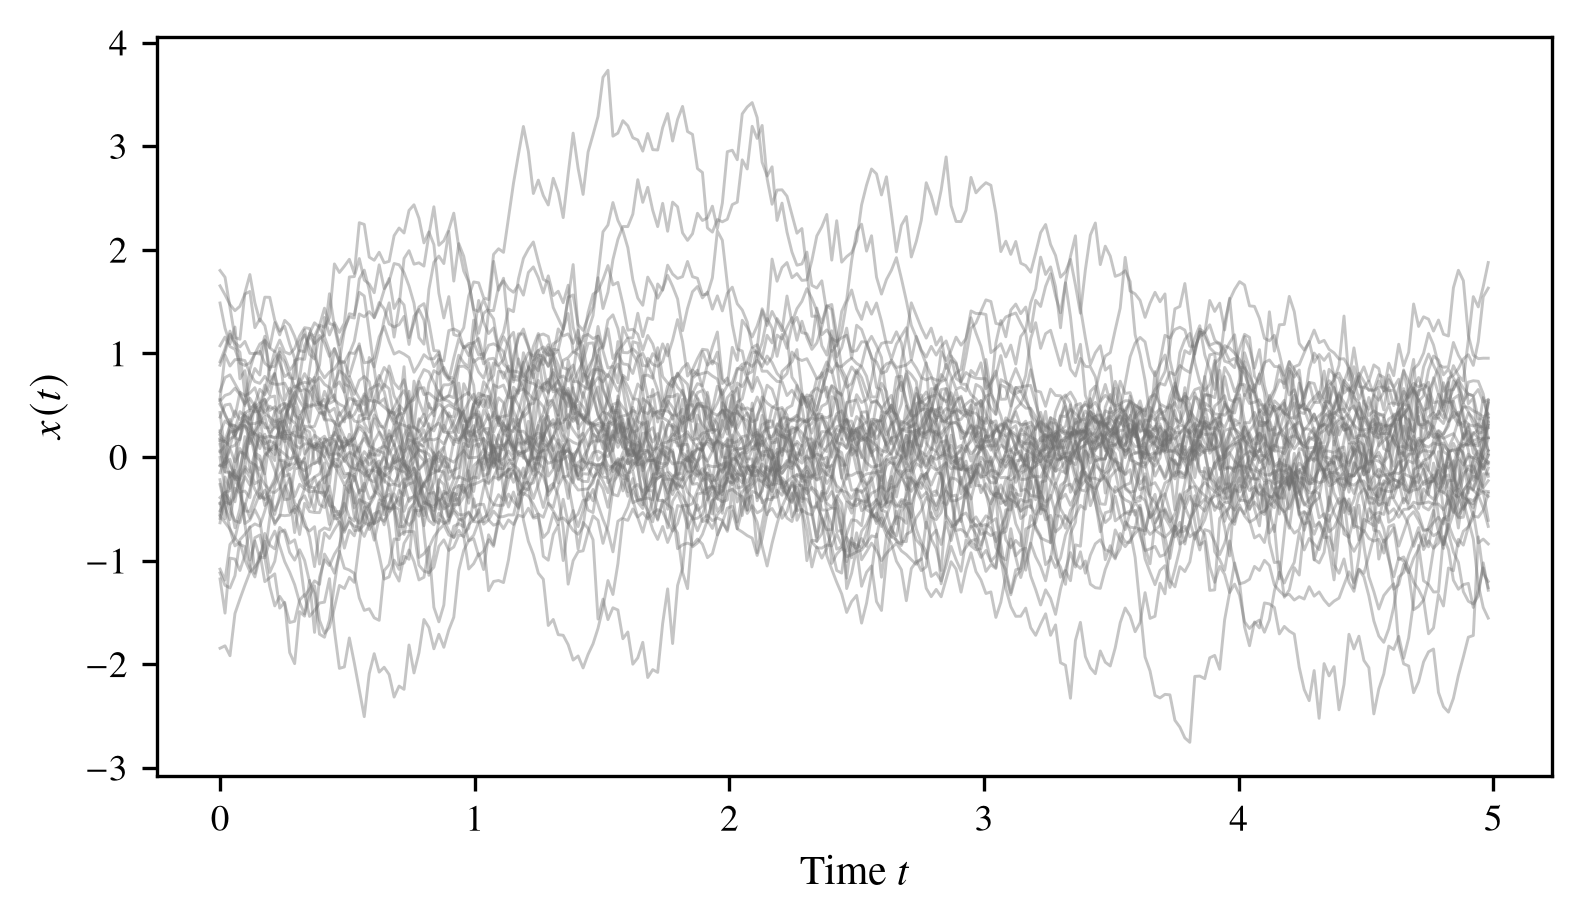

In [3]:
\
t = np.arange(N_STEPS) * DT

fig, ax = plt.subplots(figsize=(6, 3.2))
for trajectory in data_train[:40]:
    ax.plot(t, trajectory, color=REFERENCE_COLOUR, lw=0.7, alpha=0.4)
ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"$x(t)$")
plt.show()

\
## 2. Training the conditional diffusion model

The conditioning vector encodes $(\theta, D)$ in its first two entries,
z-scored with the training statistics, zero-padded to the trajectory length.
The model therefore learns $p(x(t)\,|\,\theta, D)$ over the whole parameter
box.

In [4]:
\
TRAJECTORY_LENGTH = N_STEPS

data_mean = float(data_train.mean())
data_std = float(data_train.std())
theta_mean, theta_std = float(theta_train.mean()), float(theta_train.std())
D_mean, D_std = float(D_train.mean()), float(D_train.std())


def make_dataset(theta, D, trajectories):
    x = (trajectories - data_mean) / data_std
    c = np.zeros((len(theta), TRAJECTORY_LENGTH), dtype=np.float32)
    c[:, 0] = (theta - theta_mean) / theta_std
    c[:, 1] = (D - D_mean) / D_std
    return TensorDataset(torch.tensor(x), torch.tensor(c))


config = DiffusionConfig(
    n_timesteps=1000,
    trajectory_length=TRAJECTORY_LENGTH,
    batch_size=64,
    learning_rate=2e-4,
    n_epochs=100,
    hidden_dim=64,
    n_layers=2,
    n_conditioning_channels=1,
    n_output_channels=1,
)

ddpm = DDPM(config, sampler_type="ddim", sampler_kwargs={"num_inference_steps": 200})
metrics = ddpm.fit(make_dataset(theta_train, D_train, data_train))

Training DDPM on mps...
Model parameters: 446,913


Epoch 1/100:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/100:   0%|          | 0/8 [00:00<?, ?it/s, train_loss=1.43]

Epoch 1/100:  12%|█▎        | 1/8 [00:00<00:01,  3.89it/s, train_loss=1.43]

Epoch 1/100:  12%|█▎        | 1/8 [00:00<00:01,  3.89it/s, train_loss=0.903]

...

Epoch 100/100:  50%|█████     | 4/8 [00:00<00:00, 37.39it/s, train_loss=0.0955]

Epoch 100/100:  50%|█████     | 4/8 [00:00<00:00, 37.39it/s, train_loss=0.0939]

Epoch 100/100: 100%|██████████| 8/8 [00:00<00:00, 38.32it/s, train_loss=0.0939]

Epoch 100/100: 100%|██████████| 8/8 [00:00<00:00, 38.08it/s, train_loss=0.0939]

Epoch 100: Train Loss = 0.1121
Checkpoint saved to checkpoints/256_timesteps/checkpoint_epoch_100.pt


\
## 3. Generating trajectories for held-out parameters

In [5]:
\
ddpm.freeze()

conditioning = np.zeros((len(theta_test), TRAJECTORY_LENGTH), dtype=np.float32)
conditioning[:, 0] = (theta_test - theta_mean) / theta_std
conditioning[:, 1] = (D_test - D_mean) / D_std

generated = []
with torch.no_grad():
    for start in range(0, len(conditioning), config.batch_size):
        batch = torch.tensor(conditioning[start : start + config.batch_size]).to(config.device)
        samples = ddpm.generate(batch, n_samples=1, show_progress=False)
        generated.append(samples.squeeze(1).cpu())

generated = torch.cat(generated).numpy() * data_std + data_mean
print(f"Generated ensemble: {generated.shape}")

Generated ensemble: (128, 256)


\
## 4. Comparison against the analytic benchmarks

Because the OU process is analytically tractable, we can overlay the exact
results. Both panels use only the held-out parameter pairs: the autocorrelation
is compared with $\langle e^{-\theta\tau}\rangle_\theta$ over the test
parameters, and the pooled marginal histogram with the stationary mixture
$\langle \mathcal{N}(0, D/\theta)\rangle_{(\theta,D)}$.

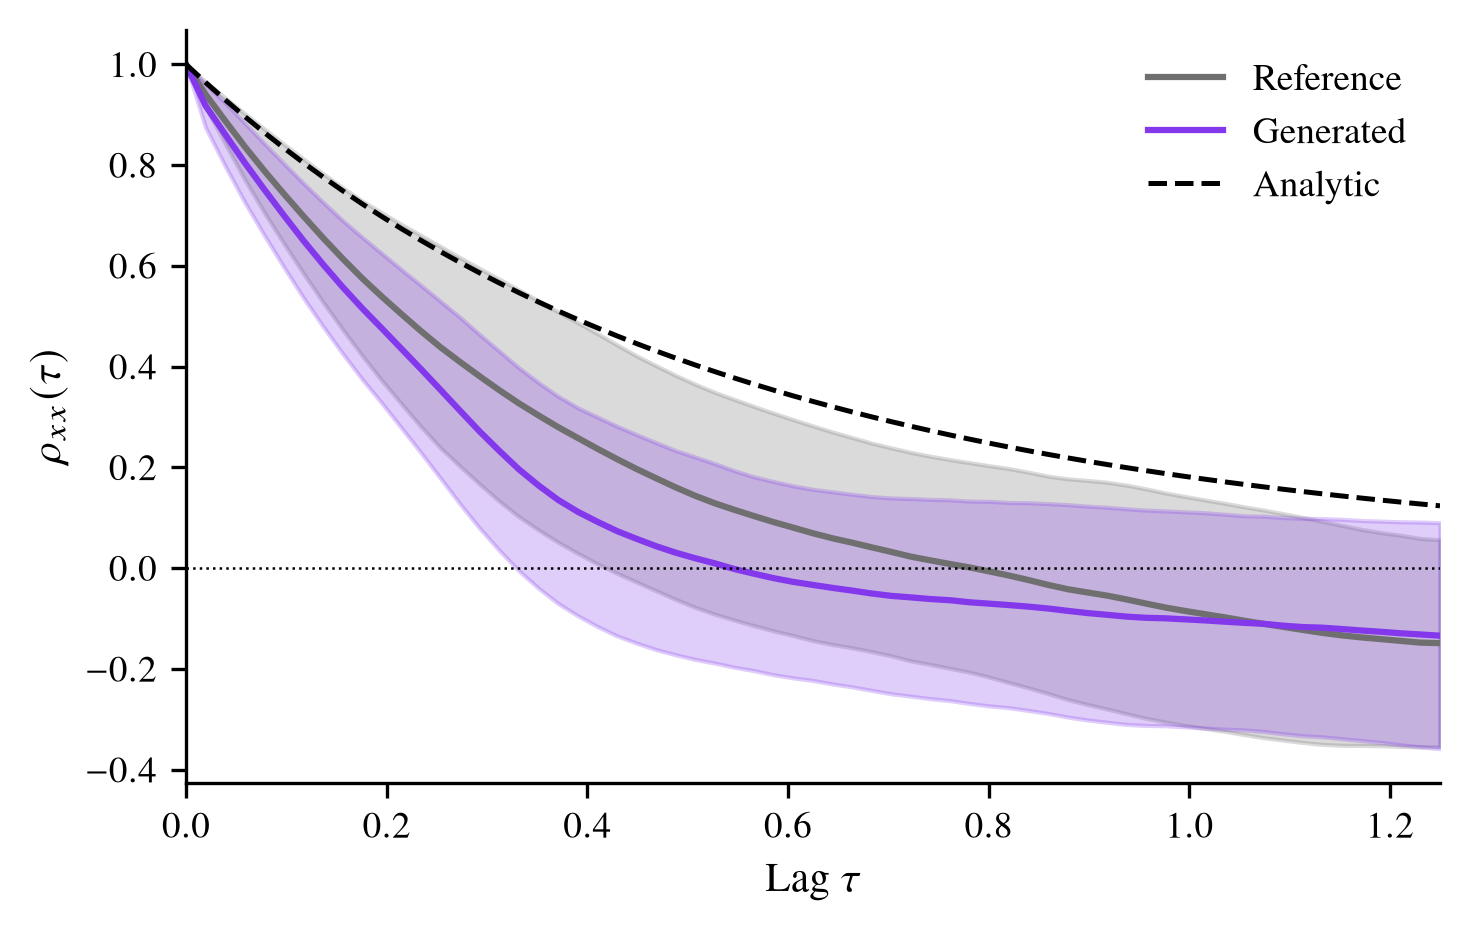

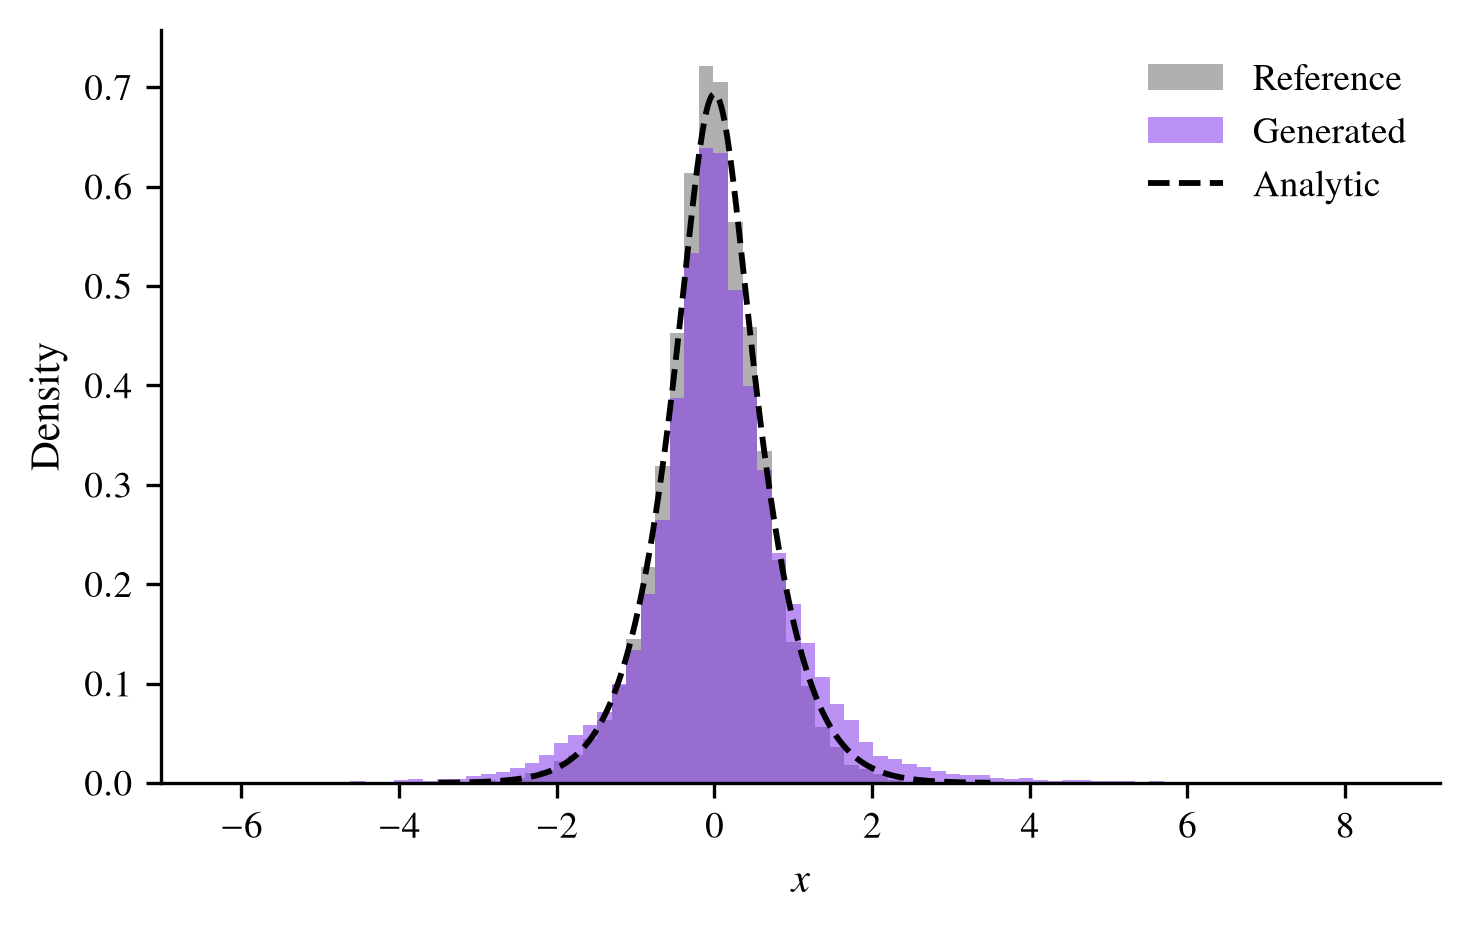

In [6]:
\
MAX_LAG = 64

acf_ref = sample_acf(torch.tensor(data_test), max_lag=MAX_LAG)
acf_gen = sample_acf(torch.tensor(generated), max_lag=MAX_LAG)
lag_axis = np.arange(MAX_LAG + 1) * DT
acf_analytic = np.exp(-theta_test[:, None] * lag_axis[None, :]).mean(axis=0)

plot_acf_comparison(
    acf_ref.mean(dim=0).numpy(), acf_gen.mean(dim=0).numpy(), lag_axis,
    real_acf_std=acf_ref.std(dim=0).numpy(),
    generated_acf_std=acf_gen.std(dim=0).numpy(),
    analytic_acf=acf_analytic,
    xlabel=r"Lag $\tau$",
    ylabel=r"$\rho_{xx}(\tau)$",
)

x_grid = np.linspace(-3.5, 3.5, 400)
pdf_analytic = np.mean([
    norm.pdf(x_grid, scale=np.sqrt(d / th))
    for th, d in zip(theta_test, D_test)
], axis=0)
plot_marginal_distribution(
    data_test, generated, xlabel=r"$x$", tail_fraction=1.0,
    analytic_pdf=(x_grid, pdf_analytic),
)
plt.show()

\
Both the exponential decay of the autocorrelation and the parameter-dependent
Gaussian width of the stationary distribution are reproduced by the generated
ensemble, with no information about the analytic form supplied to the model.
(At large lags the sample autocorrelation is biased low for both ensembles:
with a 5-unit window the per-trajectory mean subtraction imposes a zero-sum
constraint that is strongest for the slowest-relaxing trajectories. The
reference and generated curves deviate from the analytic result
consistently.)

## Where to go next

- The Duffing notebook shows the same workflow for a nonlinear, multistable
  system where no closed-form benchmarks exist.
- `StatisticsEvaluator` computes additional distributional distances
  (PSD, Wasserstein, higher moments) between reference and generated
  ensembles.